## **PCA on Wine Dataset**

This notebook demonstrates Principal Component Analysis (PCA) to reduce the dimensionality of a wine dataset and evaluates its effect on a K-Nearest Neighbors (KNN) classifier.

## 1. Imports
Import the required libraries for data manipulation, visualization, and modeling.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 2. Data Loading
Load the dataset into a pandas DataFrame.

In [ ]:
# Data Loading
import pandas as pd
df = pd.read_csv('docs/Lecture-034-wine-dataset.csv')
df.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


## 3. Data Exploration
Inspect the structure, shape, and data types of the dataset.

In [4]:
df.shape

(6497, 13)

In [5]:
df.sample(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
2561,white,6.9,0.280,0.22,10.00,0.052,36.0,131.0,0.99696,3.08,0.46,9.6,5
500,white,7.2,0.280,0.54,16.70,0.045,54.0,200.0,0.99900,3.08,0.49,9.5,6
1941,white,6.8,0.310,0.32,7.60,0.052,35.0,143.0,0.99590,3.14,0.38,9.0,5
5384,red,10.2,0.670,0.39,1.90,0.054,6.0,17.0,0.99760,3.17,0.47,10.0,5
5244,red,6.6,0.815,0.02,2.70,0.072,17.0,34.0,0.99550,3.58,0.89,12.3,7
3590,white,6.6,0.190,0.35,1.50,0.037,37.0,107.0,0.99006,3.18,0.68,12.0,7
1206,white,7.0,0.260,0.46,15.55,0.037,61.0,171.0,0.99860,2.94,0.35,8.8,6
567,white,6.0,0.260,0.50,2.20,0.048,59.0,153.0,0.99280,3.08,0.61,9.8,5
4533,white,6.1,0.250,0.18,10.50,0.049,41.0,124.0,0.99630,3.14,0.35,10.5,5
6387,red,6.2,0.570,0.10,2.10,0.048,4.0,11.0,0.99448,3.44,0.76,10.8,6


In [6]:
df['type'].unique()

<ArrowStringArray>
['white', 'red']
Length: 2, dtype: str

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   str    
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


## 4. Data Cleaning
Remove any missing values from the dataset before training.

In [8]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 6463 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6463 non-null   str    
 1   fixed acidity         6463 non-null   float64
 2   volatile acidity      6463 non-null   float64
 3   citric acid           6463 non-null   float64
 4   residual sugar        6463 non-null   float64
 5   chlorides             6463 non-null   float64
 6   free sulfur dioxide   6463 non-null   float64
 7   total sulfur dioxide  6463 non-null   float64
 8   density               6463 non-null   float64
 9   pH                    6463 non-null   float64
 10  sulphates             6463 non-null   float64
 11  alcohol               6463 non-null   float64
 12  quality               6463 non-null   int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 736.1 KB


## 5. Train-Test Split
Separate the target labels from the input features and split the data into training and testing sets.

In [9]:
X = df.iloc[: , 1:] # Input cols
y = df.iloc[: , 0] #Target

In [10]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.shape

(5170, 12)

## 6. Baseline Model
Train a KNN classifier on the raw, unreduced data to establish a performance baseline.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [13]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
import time
start = time.time()

y_pred = knn.predict(X_test)
print(f"Time taken: {time.time() - start}")

Time taken: 0.0396275520324707


In [15]:
from sklearn.metrics import accuracy_score
print(f"Without PCA Accuracy: ", accuracy_score(y_test , y_pred)*100)

Without PCA Accuracy:  94.58623356535189


## 7. Feature Scaling
PCA is highly sensitive to feature scales. Standardize the data so that it has a mean of 0 and a standard deviation of 1:

$$ z = \frac{x - \mu}{\sigma} $$

In [16]:
# PCA step 1 -> Standardize (mean centric)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Applying PCA
Reduce the dimensionality of the dataset. For the first test, we compress the 12 original features down to 3 principal components.

In [17]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=3) #Total was 12 component lets try with 3
# Find Eigen values 
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [18]:
X_train_trf.shape

(5170, 3)

## 9. Evaluating the Reduced Model
Train and evaluate a new KNN classifier using only the 3 principal components.

In [19]:
knn = KNeighborsClassifier()

In [20]:
knn.fit(X_train_trf , y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
y_pred = knn.predict(X_test_trf)

In [22]:
print("With 3 Component got Accuracy: ", accuracy_score(y_test , y_pred)*100)

With 3 Component got Accuracy:  98.14385150812065


## 10. Optimizing the Number of Components
Iterate through all possible component counts to determine which configuration yields the highest accuracy.

In [24]:
from sklearn.decomposition import PCA
maxi = 0
ind = 0
for i in range(1, 13):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf , y_train)
    y_pred = knn.predict(X_test_trf)
    print(f"Component {i} -> {(accuracy_score(y_test, y_pred) * 100):.3f}%")

    acc = accuracy_score(y_test, y_pred)
    if acc > maxi:
        maxi = acc
        ind = i

print(f"\n\nBest Result got {maxi *100:.3f} with {ind} Components")

Component 1 -> 97.834%
Component 2 -> 98.144%
Component 3 -> 98.144%
Component 4 -> 98.531%
Component 5 -> 98.531%
Component 6 -> 98.840%
Component 7 -> 98.840%
Component 8 -> 98.840%
Component 9 -> 98.917%
Component 10 -> 98.917%
Component 11 -> 98.917%
Component 12 -> 98.917%


Best Result got 98.917 with 9 Components


## 11. Cumulative Explained Variance
Plot the cumulative explained variance ratio to visualize how much information is retained as components are added.

In [25]:
pca = PCA(n_components=None)
# Find Eigen values 
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

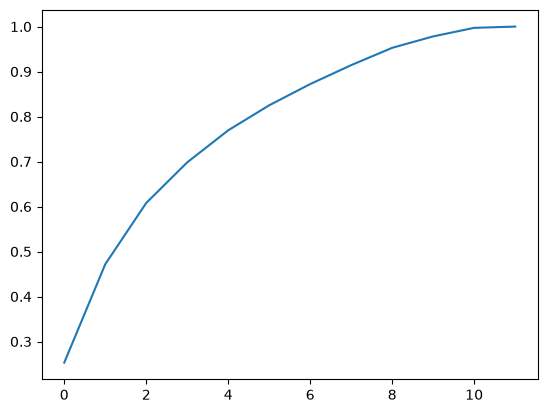

In [26]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))